# Data Exploration & Cleaning

In [25]:
import pandas as pd
df = pd.read_csv('Listings.csv', encoding='ISO-8859-1', low_memory = False)

In [26]:
df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [7]:
print(df.dtypes)

listing_id                       int64
name                            object
host_id                          int64
host_since                      object
host_location                   object
host_response_time              object
host_response_rate             float64
host_acceptance_rate           float64
host_is_superhost               object
host_total_listings_count      float64
host_has_profile_pic            object
host_identity_verified          object
neighbourhood                   object
district                        object
city                            object
latitude                       float64
longitude                      float64
property_type                   object
room_type                       object
accommodates                     int64
bedrooms                       float64
amenities                       object
price                            int64
minimum_nights                   int64
maximum_nights                   int64
review_scores_rating     

In [9]:
df['host_since'] = pd.to_datetime(df['host_since'])

In [11]:
print(df['host_since'].dtypes)

datetime64[ns]


In [61]:
duplicate_rows = df.duplicated().sum()
print(duplicate_rows)

0


In [34]:
cols = ['host_since', 'neighbourhood', 'city', 'accommodates', 'price']
paris = df[df['city'] == 'Paris'][cols].copy()

# paris = df.query("city == 'Paris'").loc[:, ["host_since", "neighbourhood", "city", "accommodates", "price"]].copy() - another way

In [35]:
print(paris.shape)  

(64690, 5)


In [16]:
print(paris.head())

  host_since      neighbourhood   city  accommodates  price
0 2011-12-03  Buttes-Montmartre  Paris             2     53
1 2013-11-29  Buttes-Montmartre  Paris             2    120
2 2014-07-31             Elysee  Paris             2     89
3 2013-12-17          Vaugirard  Paris             2     58
4 2014-12-14              Passy  Paris             2     60


In [71]:
paris['host_since'] = pd.to_datetime(paris['host_since'])

In [72]:
print(paris['host_since'].dtype)

datetime64[ns]


In [17]:
print(paris.isnull().sum())

host_since       33
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64


In [37]:
paris = paris.dropna(subset = ['host_since'])

In [38]:
print(paris.isnull().sum())

host_since       0
neighbourhood    0
city             0
accommodates     0
price            0
dtype: int64


In [39]:
print(paris.describe())

       accommodates         price
count  64657.000000  64657.000000
mean       3.037877    113.104614
std        1.588382    214.479626
min        0.000000      0.000000
25%        2.000000     59.000000
50%        2.000000     80.000000
75%        4.000000    120.000000
max       16.000000  12000.000000


# Data Analysis

In [49]:
most_expensive_neighbourhood = paris_listings_neighbourhood.iloc[-1]['neighbourhood']
print(most_expensive_neighbourhood)

Elysee


In [174]:
# Create a table named paris_listings_neighbourhood that groups Paris listings by 'neighbourhood' and calculates the mean price (sorted low to high)
paris_listings_neighbourhood = (
    paris
    .groupby('neighbourhood')['price']
    .mean()
    .sort_values()
    .reset_index()
)

# paris_listings_neighbourhood = (
#     paris
#     .groupby('neighbourhood')
#     .agg(avg_price=('price', 'mean'))
#     .sort_values('avg_price')
#     .reset_index()10                Opera  119.050713
11             Pantheon  122.696120
12               Temple  138.429300
13       Hotel-de-Ville  144.515228
14               Bourse  149.496801

# ) - another way

print(paris_listings_neighbourhood)

          neighbourhood       price
0          Menilmontant   74.911561
1       Buttes-Chaumont   82.690182
2     Buttes-Montmartre   87.222069
3               Reuilly   89.058402
4            Popincourt   90.518955
5              Gobelins   98.110184
6          Observatoire  101.873591
7   Batignolles-Monceau  102.615616
8     Enclos-St-Laurent  102.988752
9             Vaugirard  106.842073
10                Opera  119.050713
11             Pantheon  122.696120
12               Temple  138.429300
13       Hotel-de-Ville  144.515228
14               Bourse  149.496801
15           Luxembourg  155.638639
16       Palais-Bourbon  156.891525
17                Passy  161.190476
18               Louvre  175.379972
19               Elysee  210.536765


In [175]:
# Create a table named paris_listings_accomodations, filter down to the most expensive neighborhood,
# group by the ‘accommodates’ column, and add the mean price for each value of ‘accommodates’ (sorted low to high)
paris_listings_accomodations = (
    paris[paris['neighbourhood'] == most_expensive_neighbourhood].groupby('accommodates')['price']
    .mean()
    .sort_values()
)

print(paris_listings_accomodations)

accommodates
0       0.000000
1      79.522222
3     152.828767
2     155.103352
4     212.096070
5     328.817073
6     355.508571
8     405.518519
7     411.538462
9     440.272727
10    500.857143
12    529.625000
16    800.000000
11    805.000000
13    842.500000
14    971.000000
Name: price, dtype: float64


In [176]:
paris_listings_over_time = (
    paris
    .set_index("host_since") # Moves the host_since column from a regular column into the index of the DataFrame.
                             #Because resample() only works when the datetime column is the index.
    .resample("YE")  # Splits the data into yearly buckets based on the datetime index
    .agg({
        "neighbourhood": "count",
        "price": "mean"
    })
)

print(paris_listings_over_time)

            neighbourhood       price
host_since                           
2008-12-31              4   77.750000
2009-12-31            106  159.641509
2010-12-31            416  125.031250
2011-12-31           1339  124.828230
2012-12-31           4592  111.578615
2013-12-31           8142  107.096414
2014-12-31          10922  100.253800
2015-12-31          12147  103.646250
2016-12-31           8871  114.159847
2017-12-31           4585  108.658888
2018-12-31           4294  138.209362
2019-12-31           5694  129.757113
2020-12-31           3412  141.456038
2021-12-31            133   93.488722


# Data Visualization

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

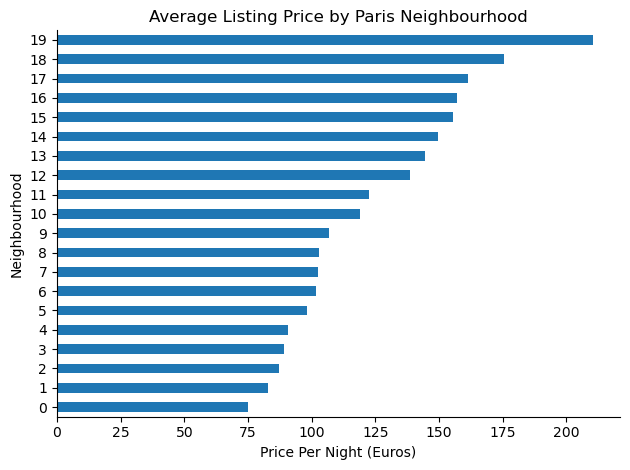

In [162]:
(paris_listings_neighbourhood
.plot
.barh(
    title = "Average Listing Price by Paris Neighbourhood",
    xlabel = "Price Per Night (Euros)",
    ylabel = "Neighbourhood",
    legend = None
))

sns.despine()
plt.tight_layout()
plt.savefig("avg_price_by_neighbourhood.png")
plt.show()

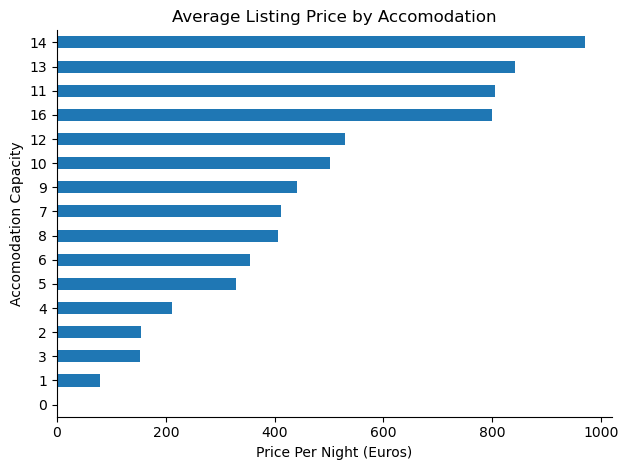

In [163]:
(paris_listings_accomodations
.plot
.barh(
    title = "Average Listing Price by Accomodation",
    xlabel = "Price Per Night (Euros)",
    ylabel = "Accomodation Capacity",
    legend = None
))

sns.despine()
plt.tight_layout()
plt.savefig("avg_price_by_accommodation.png")
plt.show()

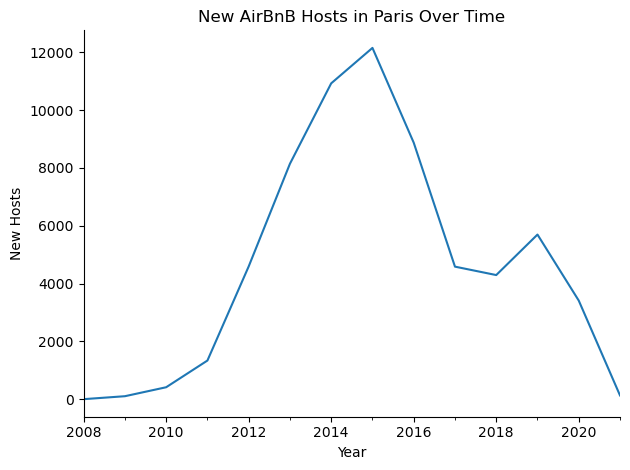

In [164]:
paris_listings_over_time['neighbourhood'].plot(
    ylabel = "New Hosts",
    xlabel = "Year",
    title = "New AirBnB Hosts in Paris Over Time")

sns.despine()
plt.tight_layout()
plt.savefig("new_hosts_over_time.png")
plt.show()

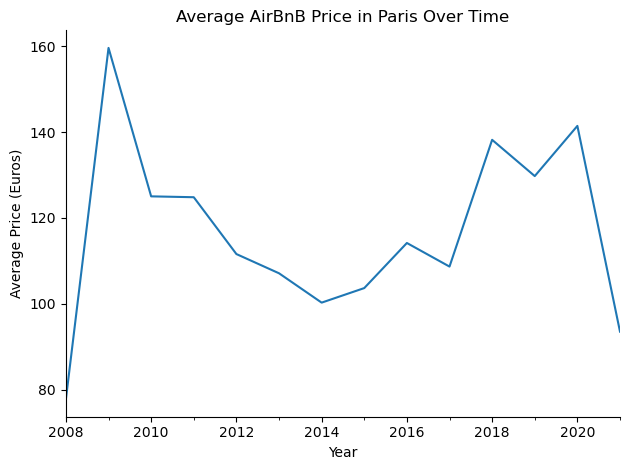

In [165]:
paris_listings_over_time['price'].plot(
    ylabel = "Average Price (Euros)",
    xlabel = "Year",
    title = "Average AirBnB Price in Paris Over Time")

sns.despine()
plt.tight_layout()
plt.savefig("avg_price_over_time.png")
plt.show()

# Automating Dashboard in EXCEL

In [92]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment

In [95]:
kpis = {
    "Total Listings"        : len(paris),
    "Average Price"         : round(paris['price'].mean(), 2),
    "Most Expensive Area"   : most_expensive_neighbourhood,
    "Cheapest Area"         : paris_listings_neighbourhood.iloc[0]['neighbourhood'],
    "Total Unique Hosts"    : paris['host_since'].nunique(),
    "Average Accommodates"  : round(paris['accommodates'].mean(), 1)
}
print(kpis)

{'Total Listings': 64657, 'Average Price': 113.1, 'Most Expensive Area': 'Elysee', 'Cheapest Area': 'Menilmontant', 'Total Unique Hosts': 3854, 'Average Accommodates': 3.0}


In [365]:
wb = Workbook()
wb.encoding = 'utf-8'
ws = wb.active
ws.title = "Dashboard"
ws.sheet_view.showGridLines = False

In [366]:
# ── Dashboard Title ──────────────────────────────────────
ws['F2'] = "Paris Airbnb Market Analysis Dashboard"
ws['F2'].font = Font(bold=True, size=28)

# KPI Section

In [367]:
ws['D6'] = "Metric"
ws['E6'] = "Value"

ws['D6'].font = Font(bold=True)
ws['E6'].font = Font(bold=True)

ws['D6'].fill = PatternFill(start_color="1F4E79", end_color="1F4E79", fill_type="solid")
ws['E6'].fill = PatternFill(start_color="1F4E79", end_color="1F4E79", fill_type="solid")

ws['D6'].font = Font(bold=True, color="FFFFFF")
ws['E6'].font = Font(bold=True, color="FFFFFF")

In [368]:
row = 7
for metric, value in kpis.items():
    ws.cell(row=row, column=4).value = metric
    ws.cell(row=row, column=5).value = value
    ws.cell(row=row, column=5).alignment = Alignment(horizontal='left')
    row += 1

In [369]:
top5_affordable = paris_listings_neighbourhood.head(5)
top5_expensive  = paris_listings_neighbourhood.tail(5).iloc[::-1]

print(top5_affordable)
print(top5_expensive)

       neighbourhood      price
0       Menilmontant  74.911561
1    Buttes-Chaumont  82.690182
2  Buttes-Montmartre  87.222069
3            Reuilly  89.058402
4         Popincourt  90.518955
     neighbourhood       price
19          Elysee  210.536765
18          Louvre  175.379972
17           Passy  161.190476
16  Palais-Bourbon  156.891525
15      Luxembourg  155.638639


# Tables and Charts

In [370]:
from openpyxl.drawing.image import Image as XLImage

In [371]:

# ── Top 5 Tables ────────────────────────────

# ── Left Table — Affordable ───────────────────────────────
ws['D22'] = "5 Most Affordable Neighbourhoods"
ws['D22'].font = Font(bold=True, color="FFFFFF")
ws['D22'].fill = PatternFill(start_color="1F4E79", end_color="1F4E79", fill_type="solid")
ws['E22'] = "Avg Price (Euros)"
ws['E22'].font = Font(bold=True, color="FFFFFF")
ws['E22'].fill = PatternFill(start_color="1F4E79", end_color="1F4E79", fill_type="solid")

row = 23                    # ← data starts at row 7 (one below header at row 6)
for _, data_row in top5_affordable.iterrows():
    ws.cell(row=row, column=4).value = data_row['neighbourhood']
    ws.cell(row=row, column=5).value = round(data_row['price'], 2)
    row += 1

# ── Right Table — Expensive ───────────────────────────────
ws['D14'] = "5 Most Expensive Neighbourhoods"
ws['D14'].font = Font(bold=True, color="FFFFFF")
ws['D14'].fill = PatternFill(start_color="1F4E79", end_color="1F4E79", fill_type="solid")
ws['E14'] = "Avg Price (Euros)"
ws['E14'].font = Font(bold=True, color="FFFFFF")
ws['E14'].fill = PatternFill(start_color="1F4E79", end_color="1F4E79", fill_type="solid")

row = 15                   # ← data starts at row 15 (one below header at row 14)
for _, data_row in top5_expensive.iterrows():
    ws.cell(row=row, column=4).value = data_row['neighbourhood']
    ws.cell(row=row, column=5).value = round(data_row['price'], 2)
    row += 1

# ── Column Widths ─────────────────────────────────────────
ws.column_dimensions['D'].width = 35
ws.column_dimensions['E'].width = 16
ws.column_dimensions['F'].width = 5
ws.column_dimensions['G'].width = 5
ws.column_dimensions['H'].width = 35
ws.column_dimensions['I'].width = 15

# ── Insert Charts ─────────────────────────────────────────
img1 = XLImage("avg_price_over_time.png")
img2 = XLImage("new_hosts_over_time.png")
img1.anchor = "G3"
img2.anchor = "G19"
ws.add_image(img1)
ws.add_image(img2)

img3 = XLImage("avg_price_by_accommodation.png")
img4 = XLImage("avg_price_by_neighbourhood.png")
img3.anchor = "K3"
img4.anchor = "K19"
ws.add_image(img3)
ws.add_image(img4)

img1.width = 400
img1.height = 300
img2.width = 400
img2.height = 300
img3.width = 400
img3.height = 300
img4.width = 400
img4.height = 300

In [372]:
# ── Save ──────────────────────────────────────────────────
wb.save("Airbnb_Market_Report.xlsx")
print("Report saved!")

Report saved!
